<a href="https://colab.research.google.com/github/iseequeue/cv_course_2025/blob/main/seminars/seminar_06/Seminar_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Семинар 6 - Классические алгоритмы сегментации изображения и обнаружения объектов

**Данный семинар содержит ДЗ**

***

In [1]:
import random as rng

import cv2
import numpy as np
import matplotlib.pyplot as plt

rng.seed(12345)

In [3]:
!mkdir -p data
!wget https://github.com/opencv/opencv/raw/4.x/samples/data/cards.png -O data/cards.png

--2025-03-31 09:09:50--  https://github.com/opencv/opencv/raw/4.x/samples/data/cards.png
Resolving github.com (github.com)... 140.82.121.3
Connecting to github.com (github.com)|140.82.121.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/cards.png [following]
--2025-03-31 09:09:51--  https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/cards.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 77914 (76K) [image/png]
Saving to: ‘data/cards.png’

data/cards.png      100%[===================>]  76.09K  --.-KB/s    in 0.009s  

2025-03-31 09:09:51 (8.70 MB/s) - ‘data/cards.png’ saved [77914/77914]



# Image Segmentation with Distance Transform and Watershed Algorithm

Источник - https://docs.opencv.org/3.4/d2/dbd/tutorial_distance_transform.html

В этом семинаре вы узнаете, как:

- Использовать `cv2.filter2D`, чтобы выполнить фильтрацию Лапласа для повышения резкости изображения.
- Использовать `cv2.distanceTransform`, чтобы получить производное представление двоичного изображения, где значение каждого пикселя заменяется его расстоянием до ближайшего пикселя фона.
- Использовать `cv2.watershed`, чтобы изолировать объекты на изображении от фона.

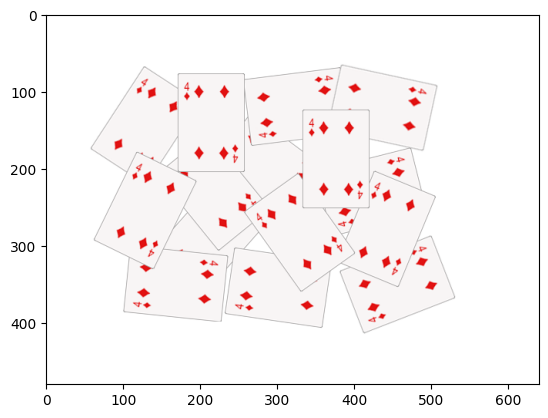

In [4]:
img_src = cv2.cvtColor(cv2.imread("data/cards.png"), cv2.COLOR_BGR2RGB)
plt.imshow(img_src);

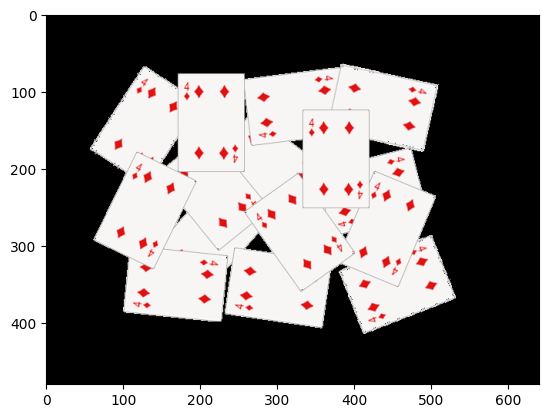

In [5]:
# Change the background from white to black, since that will help later to extract
# better results during the use of Distance Transform
img = img_src.copy()
img[np.all(img == 255, axis=2)] = 0

plt.imshow(img);

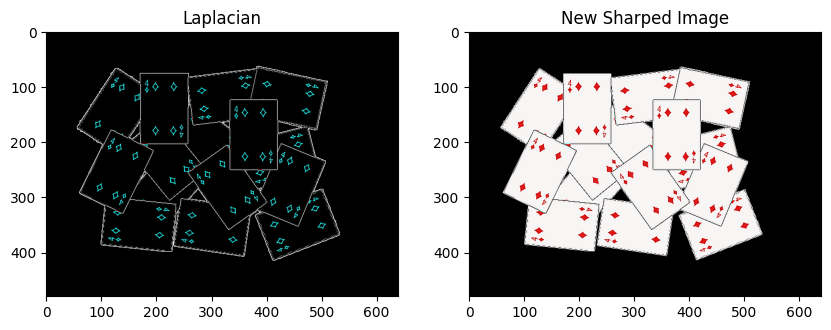

In [6]:
# Create a kernel that we will use to sharpen our image
# an approximation of second derivative, a quite strong kernel
kernel = np.array(
    [[  1,  1,  1],
     [  1, -8,  1],
     [  1,  1,  1]], dtype=np.float32)
# do the laplacian filtering as it is
# well, we need to convert everything in something more deeper then CV_8U
# because the kernel has some negative values,
# and we can expect in general to have a Laplacian image with negative values
# BUT a 8bits unsigned int (the one we are working with) can contain values from 0 to 255
# so the possible negative number will be truncated
imgLaplacian = cv2.filter2D(img, cv2.CV_32F, kernel)
sharp = np.float32(img)
imgResult = sharp - imgLaplacian

# convert back to 8bits gray scale
imgResult = np.clip(imgResult, 0, 255)
imgResult = imgResult.astype('uint8')
imgLaplacian = np.clip(imgLaplacian, 0, 255)
imgLaplacian = np.uint8(imgLaplacian)

plt.figure(figsize=(10, 5))
plt.subplot(121)
plt.imshow(imgLaplacian)
plt.title('Laplacian')
plt.subplot(122)
plt.imshow(imgResult)
plt.title('New Sharped Image');

### Бинаризация изображения

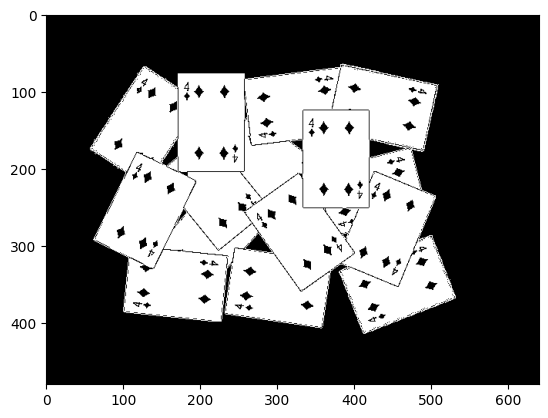

In [7]:
# Create binary image from source image
bw = cv2.cvtColor(imgResult, cv2.COLOR_BGR2GRAY)
_, bw = cv2.threshold(bw, 40, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
plt.imshow(bw, cmap="Greys_r");

### Distance transform

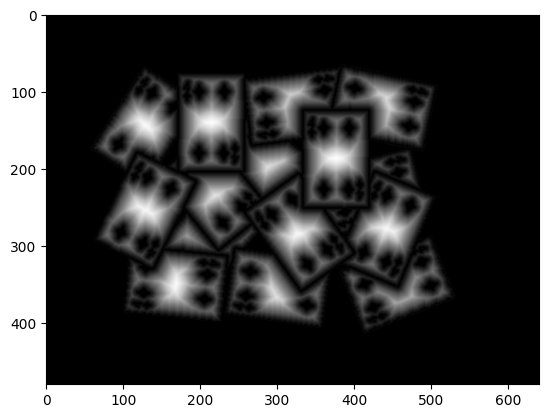

In [8]:
# Perform the distance transform algorithm
dist = cv2.distanceTransform(bw, cv2.DIST_L2, 3)
# Normalize the distance image for range = {0.0, 1.0}
# so we can visualize and threshold it
cv2.normalize(dist, dist, 0, 1.0, cv2.NORM_MINMAX)
plt.imshow(dist, cmap="Greys_r");

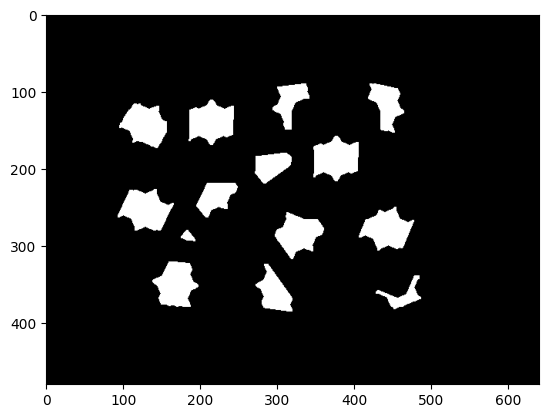

In [9]:
# Threshold to obtain the peaks
# This will be the markers for the foreground objects
_, dist = cv2.threshold(dist, 0.4, 1.0, cv2.THRESH_BINARY)
# Dilate a bit the dist image
kernel1 = np.ones((3,3), dtype=np.uint8)
dist = cv2.dilate(dist, kernel1)
plt.imshow(dist, cmap="Greys_r");

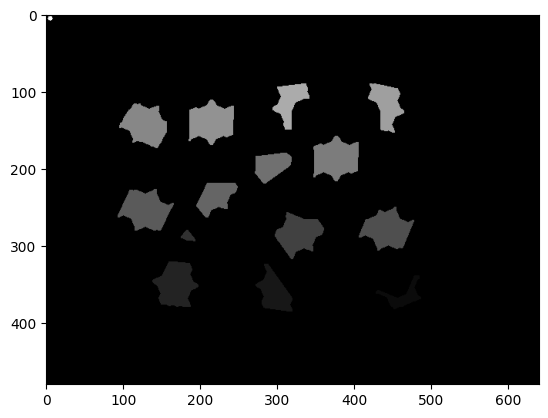

In [10]:
# Create the CV_8U version of the distance image
# It is needed for findContours()
dist_8u = dist.astype('uint8')
# Find total markers
contours, _ = cv2.findContours(dist_8u, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
# Create the marker image for the watershed algorithm
markers = np.zeros(dist.shape, dtype=np.int32)
# Draw the foreground markers
for i in range(len(contours)):
    cv2.drawContours(
        markers,   # image
        contours,  # contours list
        i,         # contour index to draw
        (i+1),     # color (fill value)
        -1,        # thickness (if negative - fill the contour)
    )
# Draw the background marker
cv2.circle(
    markers,        # image
    (5,5),          # center
    3,              # radius
    (255,255,255),  # color
    -1,             # thickness (if negative - fill)
)

markers_8u = (markers * 10).astype('uint8')
plt.imshow(markers_8u, cmap="Greys_r");

### Алгоритм Watershed

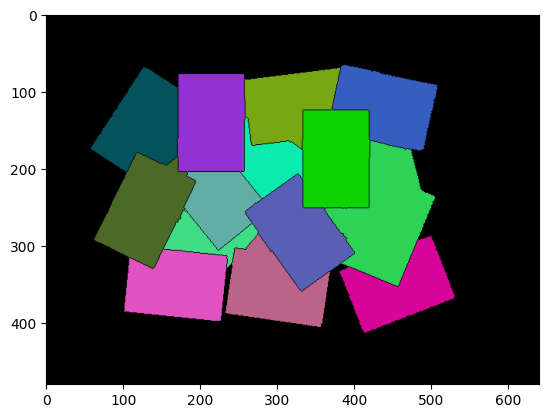

In [11]:
# Perform the watershed algorithm
cv2.watershed(imgResult, markers)

mark = markers.astype('uint8')
mark = cv2.bitwise_not(mark)
# uncomment this if you want to see how the mark
# image looks like at that point
# plt.imshow(mark)
# Generate random colors
colors = []
for contour in contours:
    colors.append((rng.randint(0,256), rng.randint(0,256), rng.randint(0,256)))
# Create the result image
dst = np.zeros((markers.shape[0], markers.shape[1], 3), dtype=np.uint8)
# Fill labeled objects with random colors
for i in range(markers.shape[0]):
    for j in range(markers.shape[1]):
        index = markers[i,j]
        if index > 0 and index <= len(contours):
            dst[i,j,:] = colors[index-1]

# Visualize the final image
plt.imshow(dst);

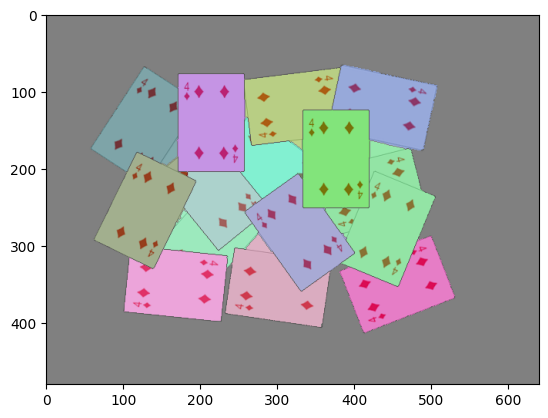

In [12]:
blended = cv2.addWeighted(img_src, 0.5, dst, 0.5, 0.0)
plt.imshow(blended);

# Домашнее задание: подсчет количества пальцев

**Это оцениваемое ДЗ**

Вам предлагается реализовать алгоритм, подсчитывающий количество пальцев.

Один из возможных вариантов решения:
- Получить бинаризованное изображение и найти контур руки;
- Построить выпуклый контур функцией `cv2.convexHull` - https://docs.opencv.org/3.4/d7/d1d/tutorial_hull.html
- Найти дефекты выпуклости контура функцией [`cv2.convexityDefects`](https://docs.opencv.org/3.4/d3/dc0/group__imgproc__shape.html#gada4437098113fd8683c932e0567f47ba)
- После некоторой фильтрации дефектов, их число будет напрямую коррелировать с числом пальцев.

**Требования:**
1. Продемонстрируйте работоспособность алгоритма на любом числе пальцев (от 0 до 5).
2. Используйте фото своей руки для демонстрации (предложенное фото лишь для отладки).

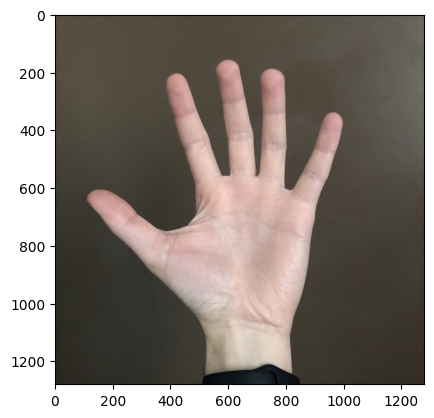

In [ ]:
img = cv2.cvtColor(cv2.imread("data/hand.jpg"), cv2.COLOR_BGR2RGB)
plt.imshow(img);

In [25]:
import cv2
import numpy as np

def count_fingers(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) == 0:
        return 0

    hand_contour = max(contours, key=cv2.contourArea)

    hull = cv2.convexHull(hand_contour, returnPoints=False)
    defects = cv2.convexityDefects(hand_contour, hull)

    if defects is None:
        return 0

    finger_count = 0
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i, 0]
        start = tuple(hand_contour[s][0])
        end = tuple(hand_contour[e][0])
        far = tuple(hand_contour[f][0])

        a = np.linalg.norm(np.array(end) - np.array(far))
        b = np.linalg.norm(np.array(start) - np.array(far))
        c = np.linalg.norm(np.array(start) - np.array(end))
        angle = np.arccos((a**2 + b**2 - c**2) / (2 * a * b)) * 180 / np.pi

        # Игнорируем маленькие углы (не пальцы)
        if angle < 90 and d > 10000:
            finger_count += 1
            cv2.circle(img, far, 5, (0, 0, 255), -1)

    # Количество пальцев = количество дефектов + 1 (если есть хотя бы один дефект)
    return finger_count + 1 if finger_count > 0 else 0

image_path = "1.png"
count = count_fingers(image_path)
print(f"Количество пальцев: {count}")

Количество пальцев: 0


In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [40]:
def count_fingers_with_steps(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    original = img.copy()

    # 1. Преобразование в градации серого
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Размытие изображения
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # 3. Бинаризация (Otsu)
    _, thresh = cv2.threshold(blurred, 60, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # 4. Поиск контуров
    contours, _ = cv2.findContours(thresh.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

    if len(contours) == 0:
        print("Контуры не найдены")
        return 0, []

    # 5. Выбор наибольшего контура (рука)
    hand_contour = max(contours, key=cv2.contourArea)
    contour_img = original.copy()
    cv2.drawContours(contour_img, [hand_contour], -1, (0, 255, 0), 2)

    # 6. Построение выпуклой оболочки
    hull = cv2.convexHull(hand_contour, returnPoints=False)
    hull_points = cv2.convexHull(hand_contour, returnPoints=True)
    hull_img = original.copy()
    cv2.drawContours(hull_img, [hull_points], -1, (0, 255, 0), 2)

    # 7. Поиск дефектов выпуклости
    defects = cv2.convexityDefects(hand_contour, hull)

    if defects is None:
        print("Дефекты не найдены")
        return 0, []

    # 8. Фильтрация дефектов и подсчет пальцев
    result_img = original.copy()
    cv2.drawContours(result_img, [hull_points], -1, (0, 255, 0), 2)
    cv2.drawContours(result_img, [hand_contour], -1, (255, 0, 0), 2)

    finger_count = 0
    for i in range(defects.shape[0]):
        s, e, f, d = defects[i, 0]
        start = tuple(hand_contour[s][0])
        end = tuple(hand_contour[e][0])
        far = tuple(hand_contour[f][0])

        a = np.linalg.norm(np.array(end) - np.array(far))
        b = np.linalg.norm(np.array(start) - np.array(far))
        c = np.linalg.norm(np.array(start) - np.array(end))
        angle = np.arccos((a**2 + b**2 - c**2) / (2 * a * b)) * 180 / np.pi

        if angle < 90 and d > 10000:
            finger_count += 1
            cv2.circle(result_img, far, 8, [0, 0, 255], -1)
            cv2.line(result_img, start, end, [0, 255, 0], 2)

    finger_count = finger_count + 1 if finger_count > 0 else 0

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 3, 1)
    plt.imshow(img_rgb)
    plt.title('Исходное изображение')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(gray, cmap='gray')
    plt.title('Градации серого')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(thresh, cmap='gray')
    plt.title('Бинаризация (Otsu)')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(cv2.cvtColor(contour_img, cv2.COLOR_BGR2RGB))
    plt.title('Контур руки')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(cv2.cvtColor(hull_img, cv2.COLOR_BGR2RGB))
    plt.title('Выпуклая оболочка')
    plt.axis('off')

    plt.subplot(2, 3, 6)
    plt.imshow(cv2.cvtColor(result_img, cv2.COLOR_BGR2RGB))
    plt.title(f'Результат: {finger_count} пальцев')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return finger_count, [gray, thresh, contour_img, hull_img, result_img]

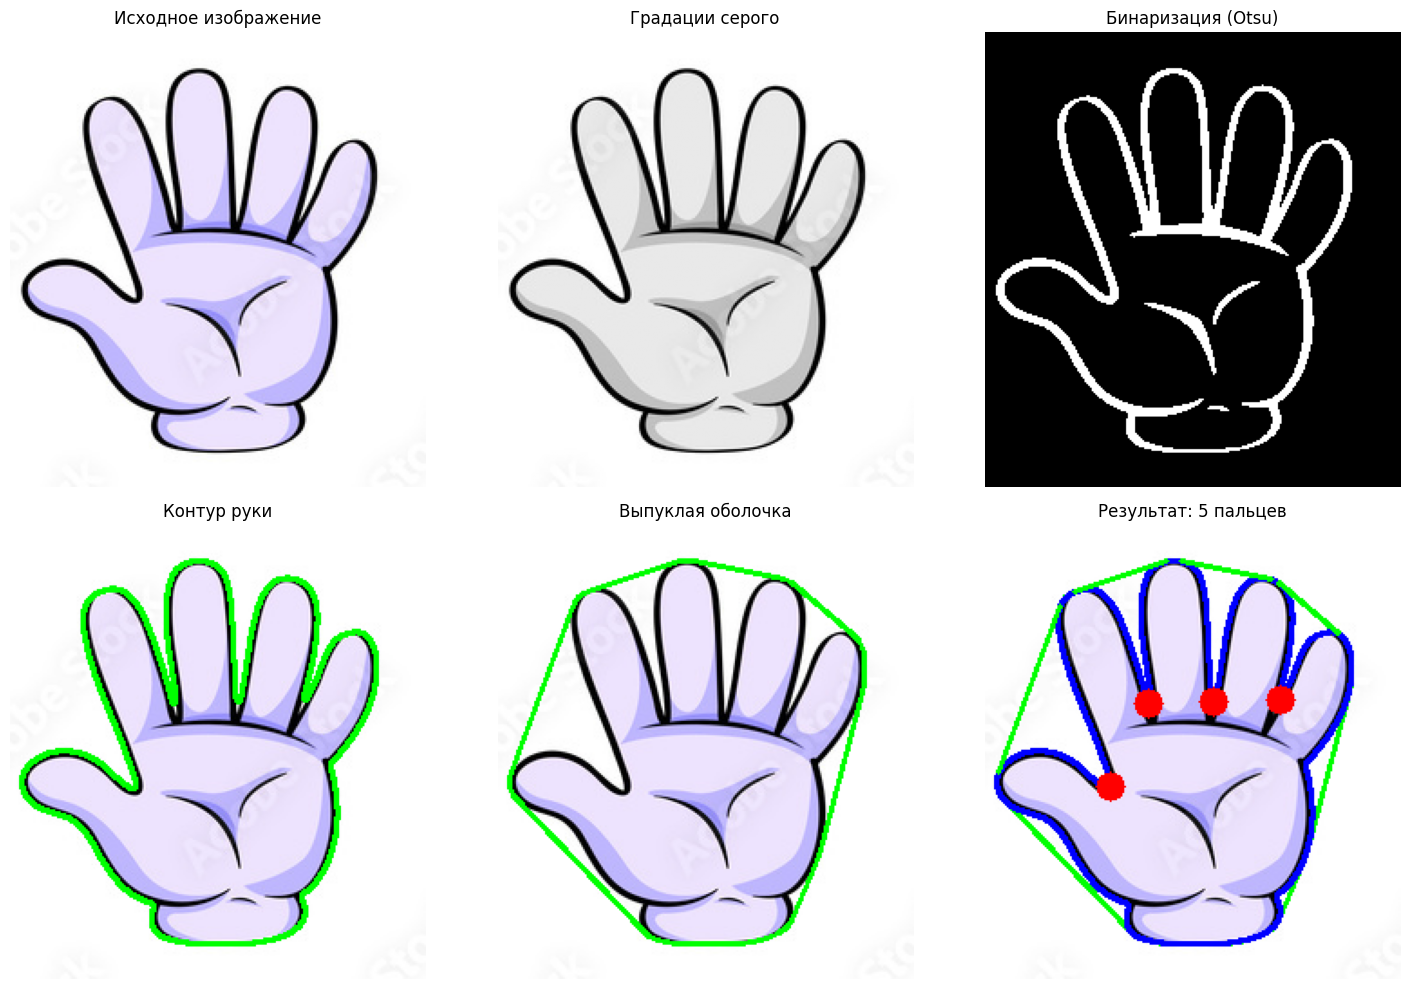

Количество пальцев: 5


In [42]:
image_path = "5.png"
count, steps = count_fingers_with_steps(image_path)
print(f"Количество пальцев: {count}")

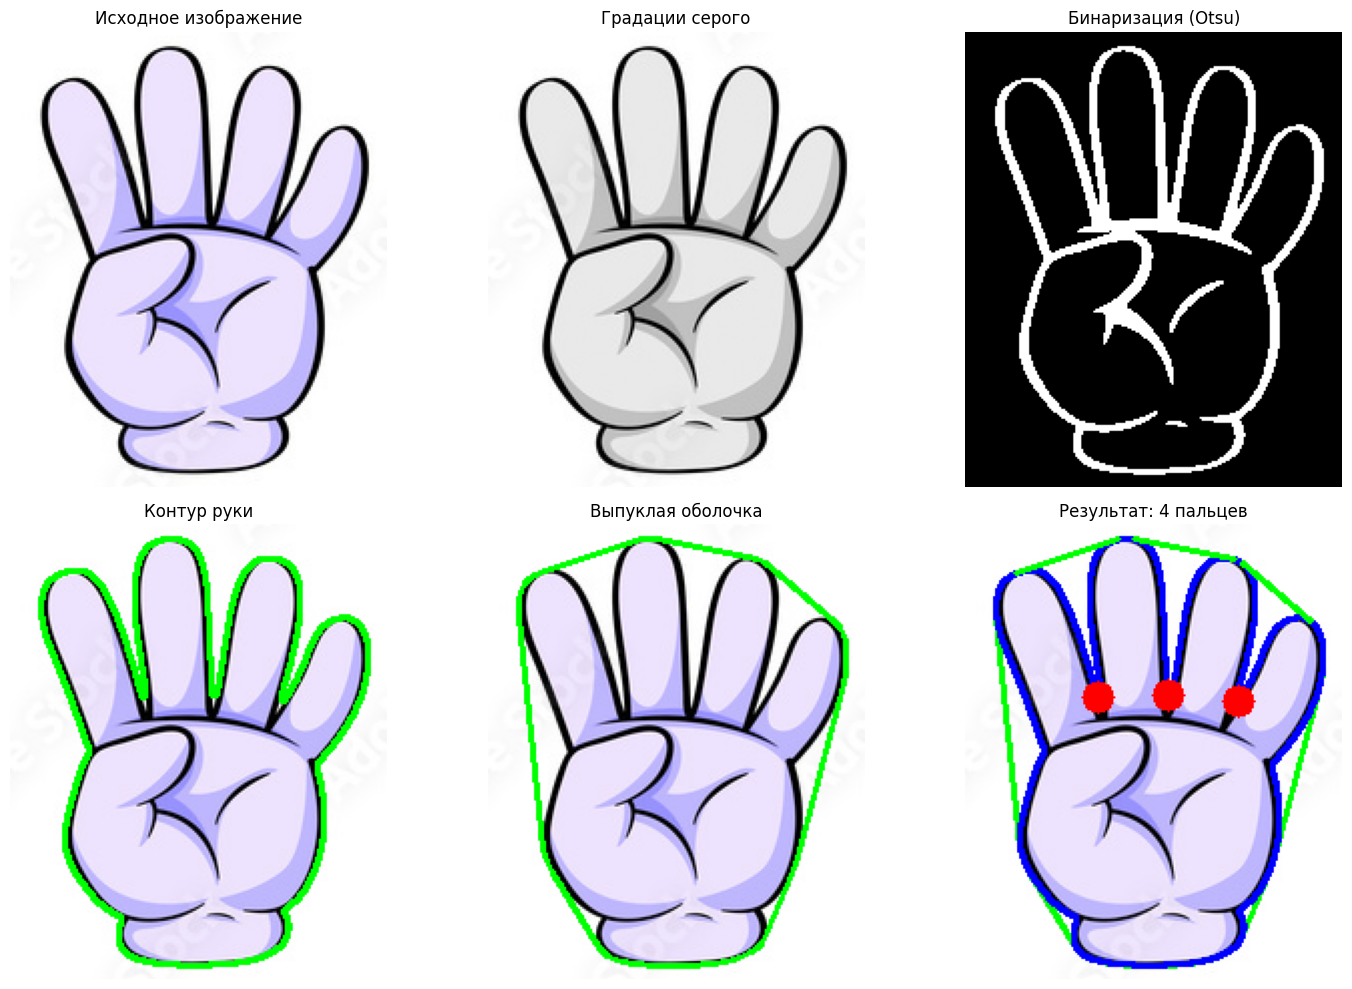

Количество пальцев: 4


In [43]:
image_path = "4.png"
count, steps = count_fingers_with_steps(image_path)
print(f"Количество пальцев: {count}")

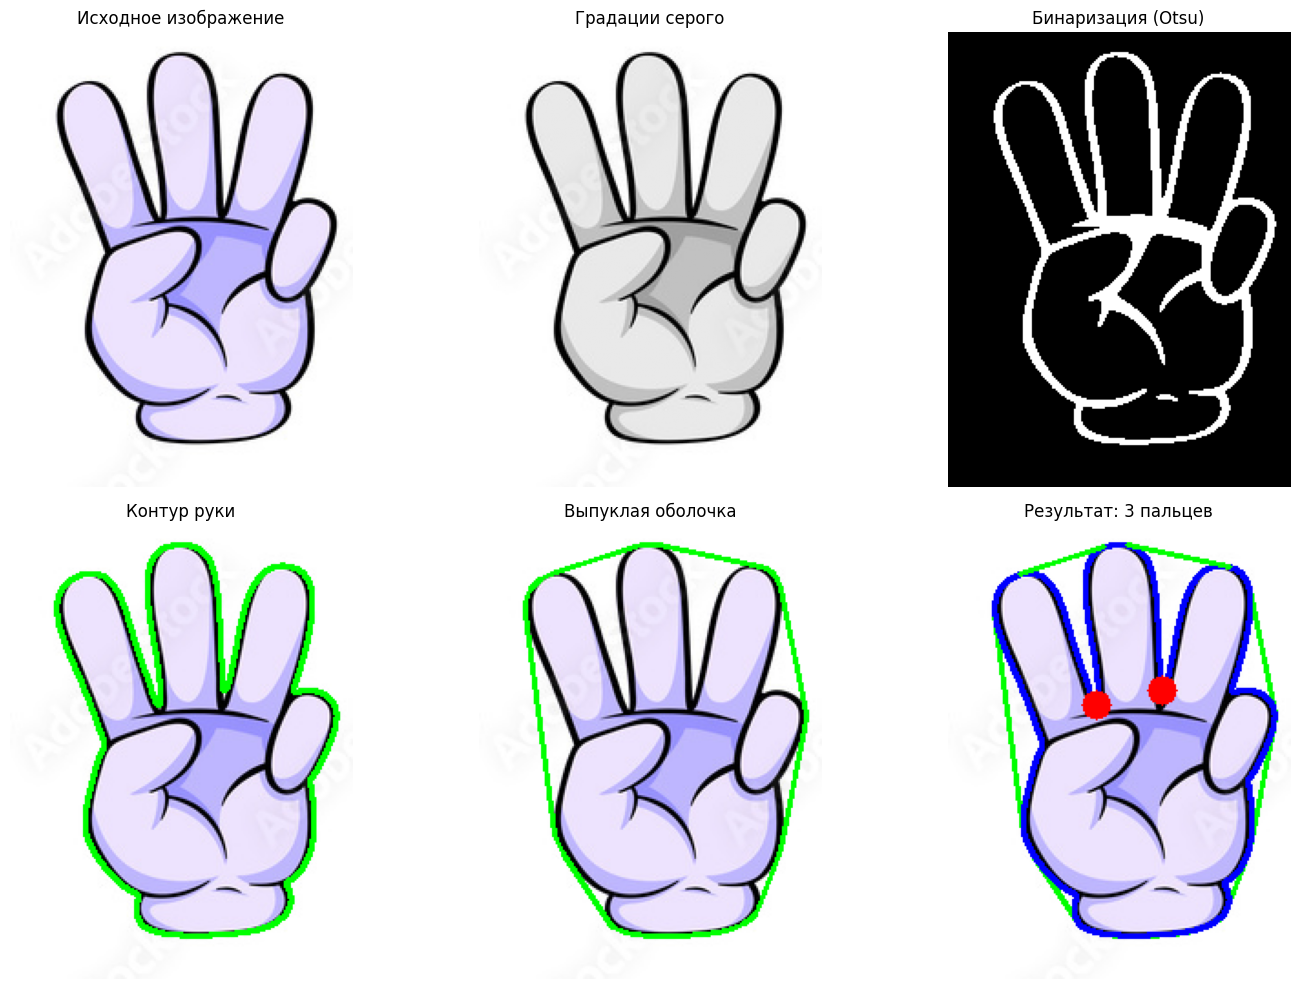

Количество пальцев: 3


In [44]:
image_path = "3.png"
count, steps = count_fingers_with_steps(image_path)
print(f"Количество пальцев: {count}")

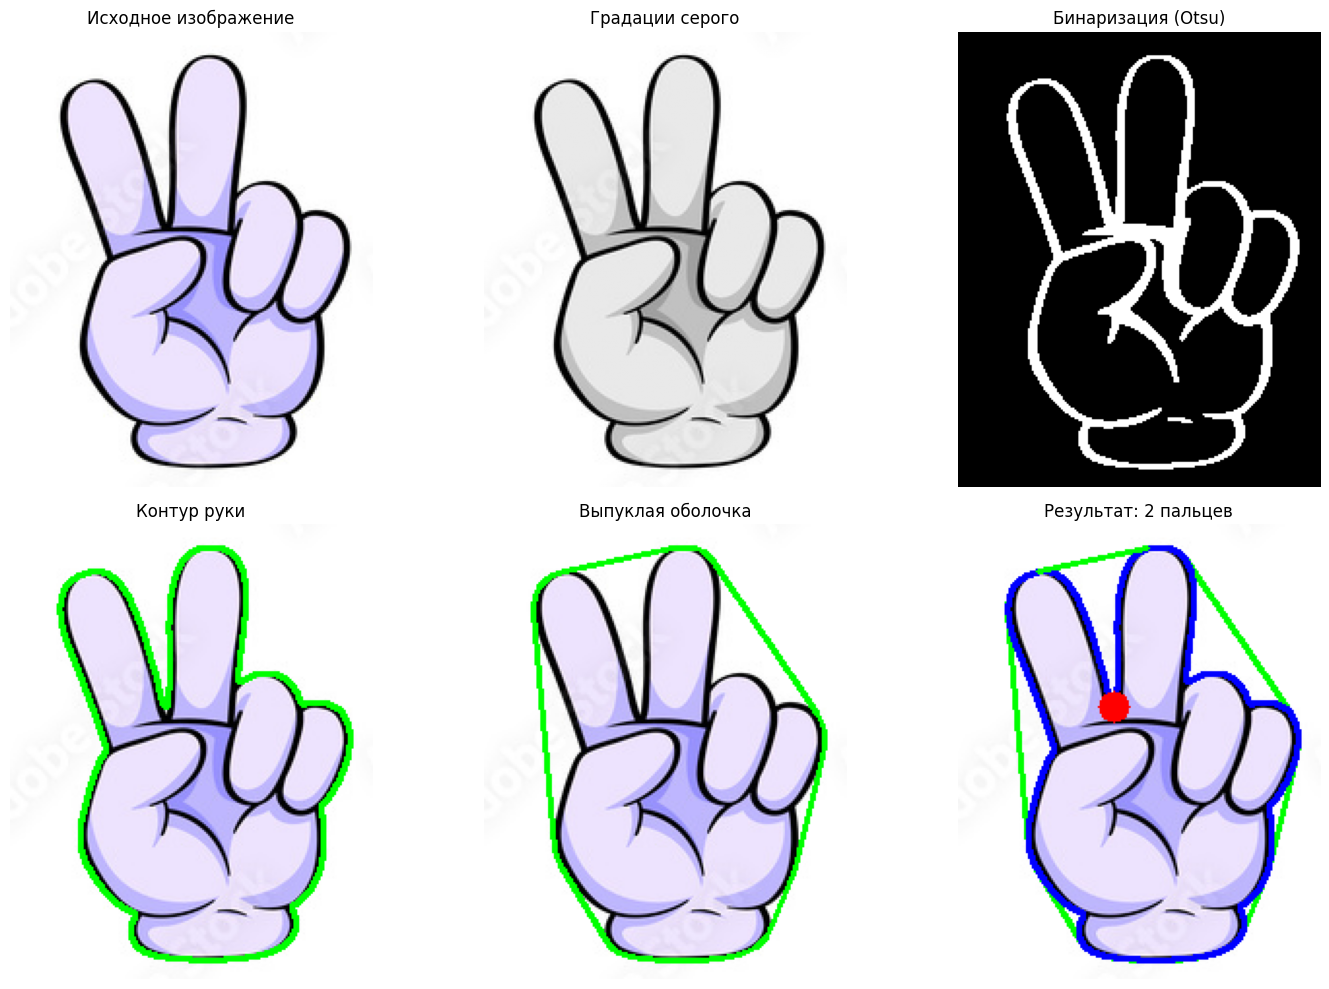

Количество пальцев: 2


In [45]:
image_path = "2.png"
count, steps = count_fingers_with_steps(image_path)
print(f"Количество пальцев: {count}")

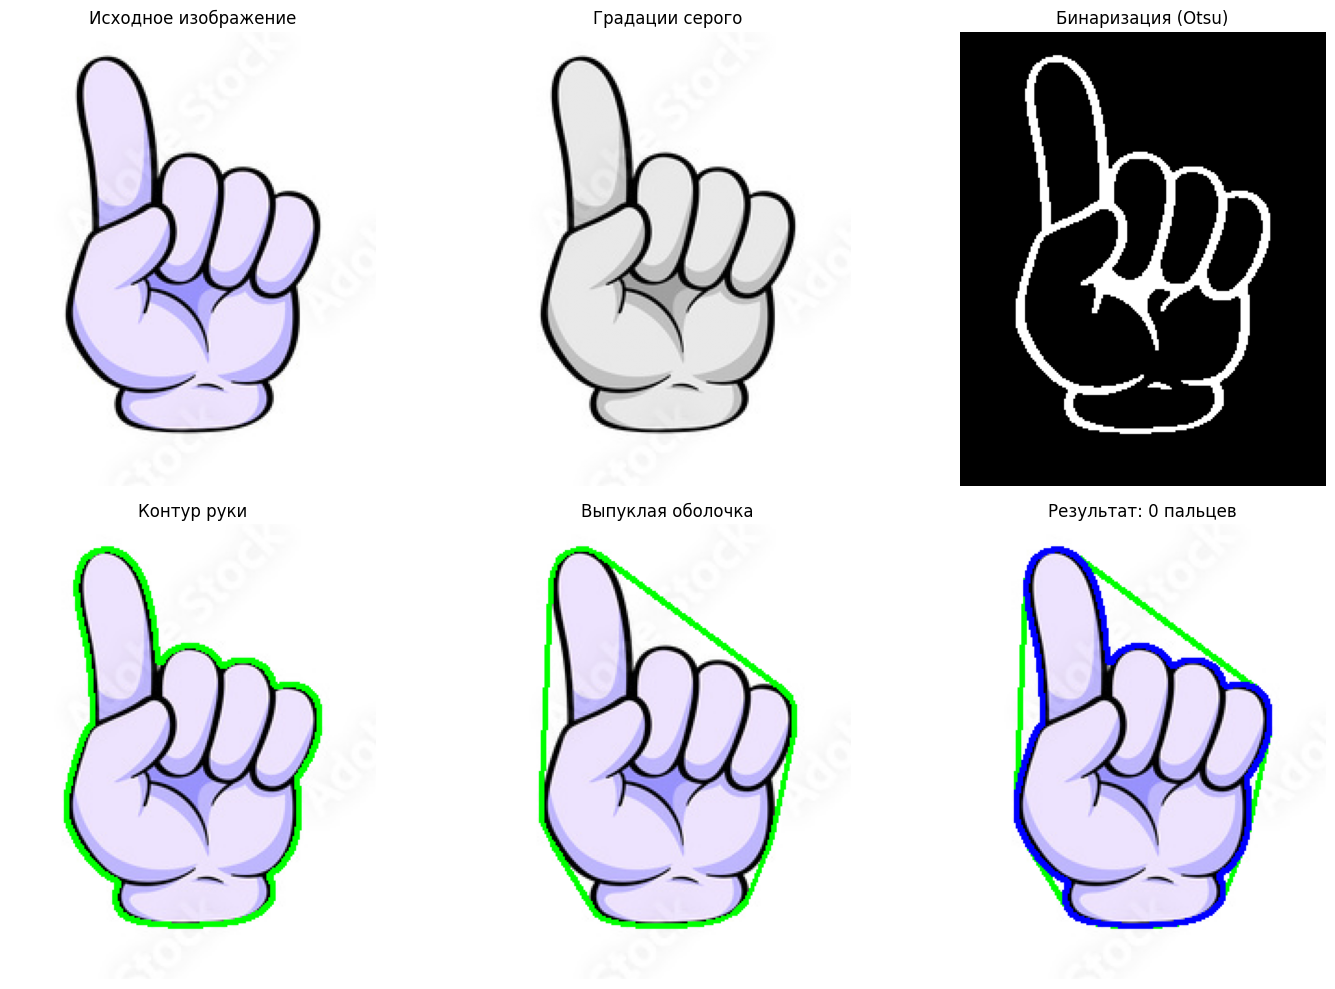

Количество пальцев: 0


In [46]:
image_path = "1.png"
count, steps = count_fingers_with_steps(image_path)
print(f"Количество пальцев: {count}")

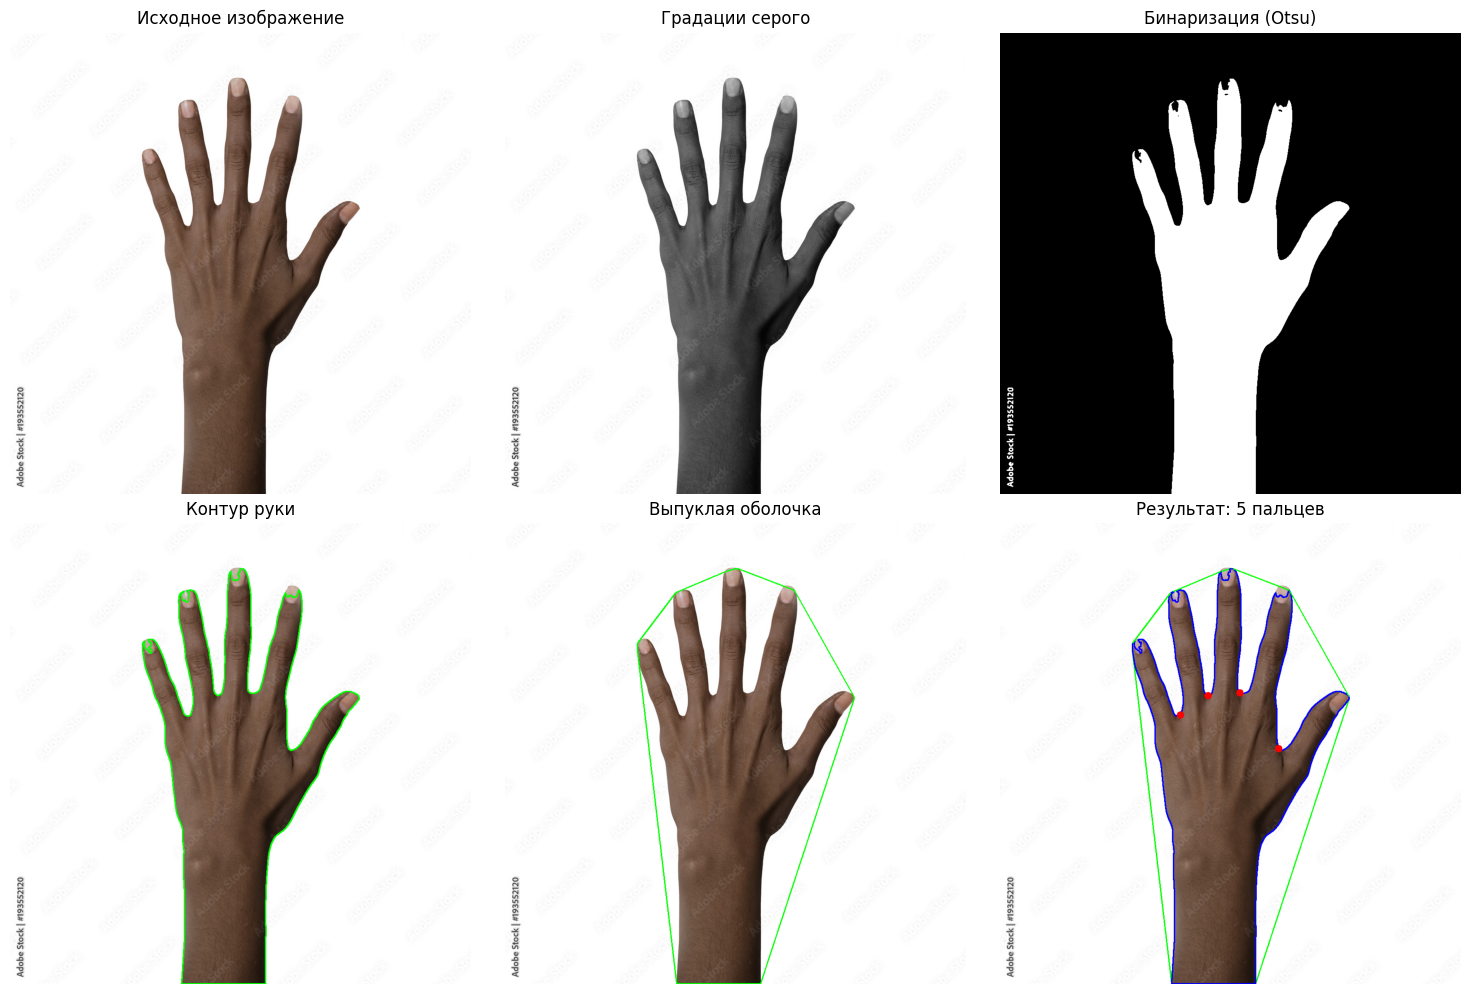

Количество пальцев: 5


In [47]:
image_path = "black.jpg"
count, steps = count_fingers_with_steps(image_path)
print(f"Количество пальцев: {count}")

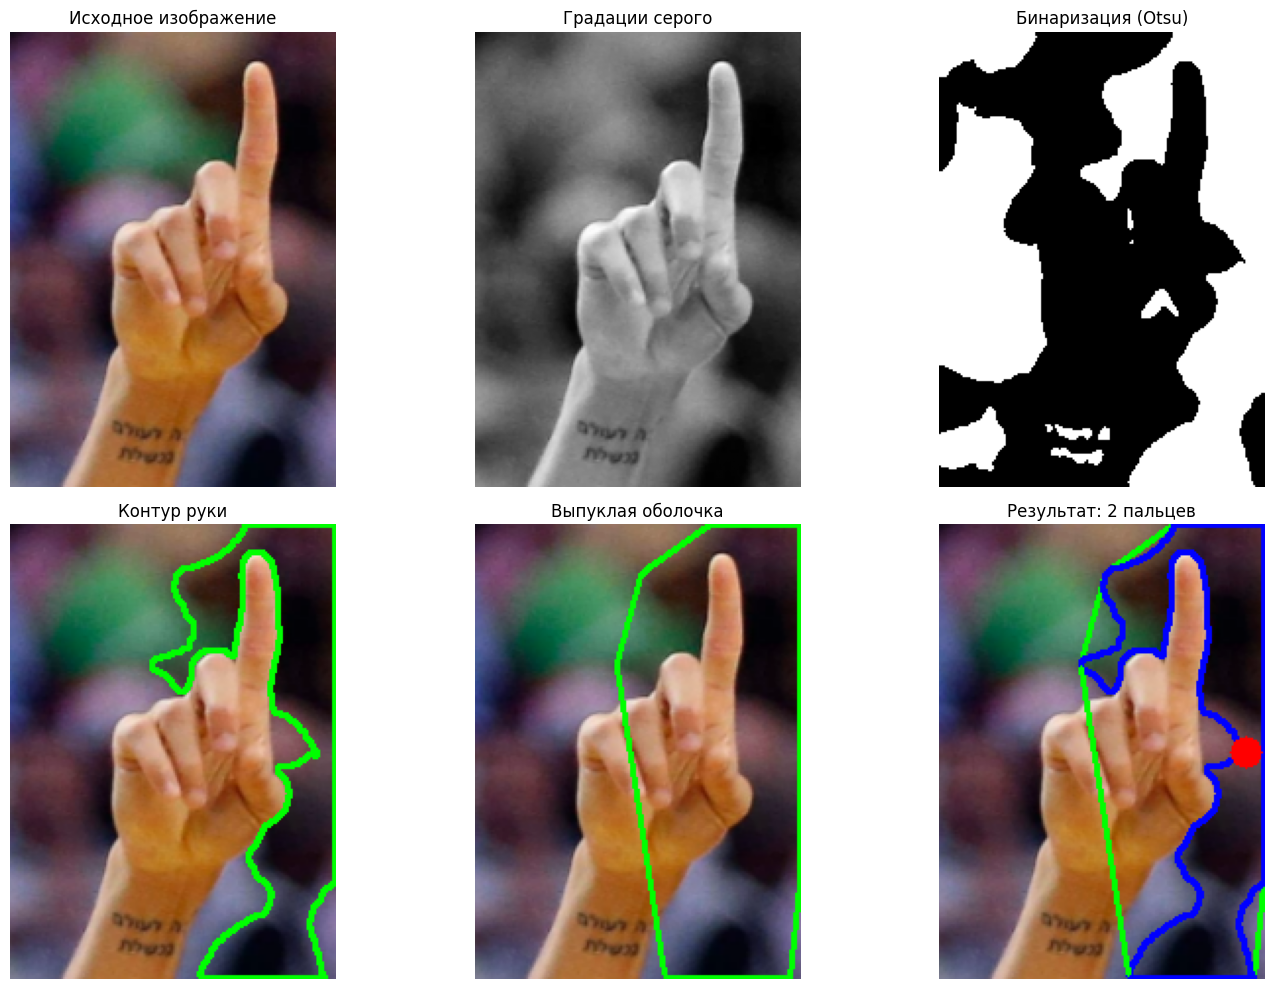

Количество пальцев: 2


In [34]:
image_path = "steph_1.png"

count, steps = count_fingers_with_steps(image_path)
print(f"Количество пальцев: {count}")

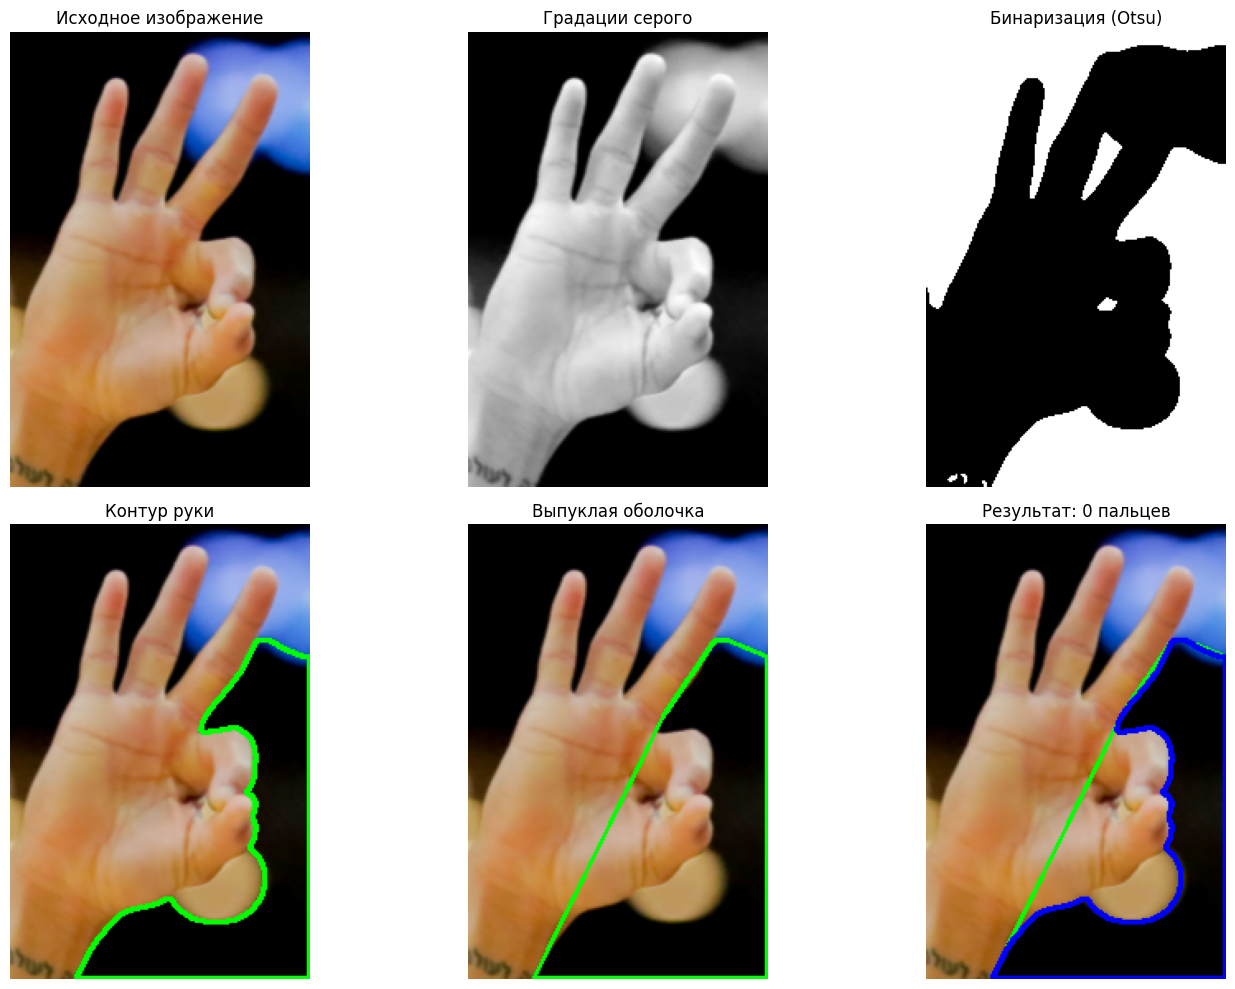

Количество пальцев: 0


In [35]:
image_path = "steph_3_1.png"

count, steps = count_fingers_with_steps(image_path)
print(f"Количество пальцев: {count}")

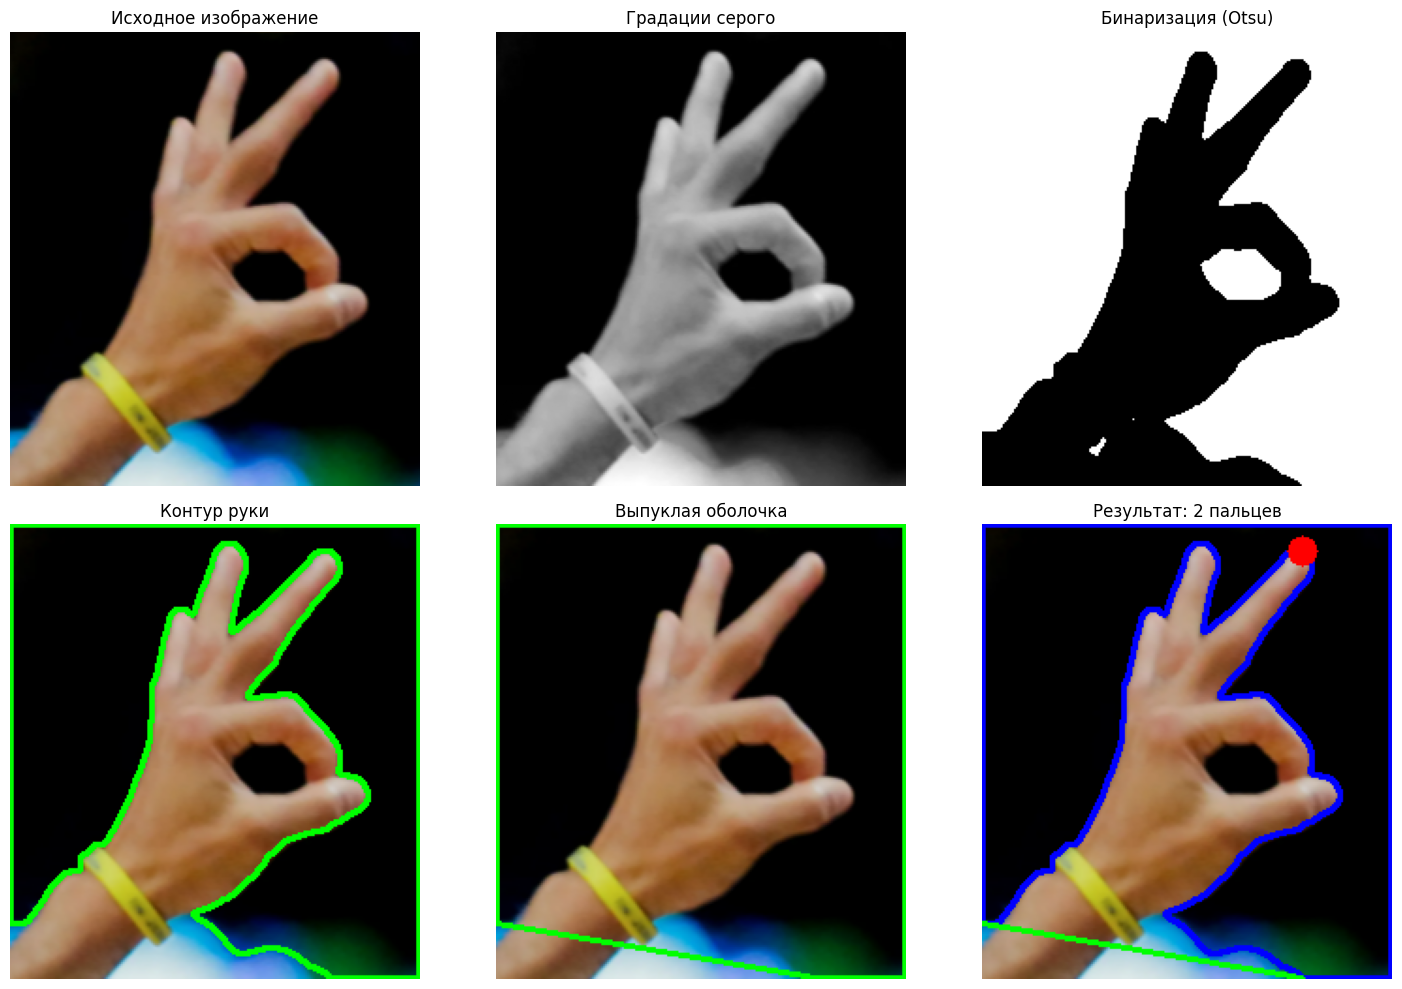

Количество пальцев: 2


In [36]:
image_path = "steph_3_2.png"

count, steps = count_fingers_with_steps(image_path)
print(f"Количество пальцев: {count}")